<a href="https://colab.research.google.com/github/BrionesC/Campo_magnetico/blob/main/Tesis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== Comparativa Cobre AWG18 (Bobina simple) ===
     N  V (V)  I_exp (A)  I_teo (A)  Error_I (%)  B_exp (mT)  B_teo (mT)  \
0   71   14.0       13.0  28.677135    54.667717        1.52   25.586093   
1  180   14.0        7.0  11.613292    39.724239        0.14   26.268647   

    Error_B (%)  
0  9.405927e+07  
1  9.946705e+07  

=== Comparativa Aluminio AWG19 (Helmholtz) ===
     N    Config  V (V)  I_exp (A)  I_teo (A)  Error_I (%)  B_exp (mT)  \
0  171     Serie   14.0       1.20   2.697340    55.511721         3.0   
1  340     Serie   14.0       0.70   1.367918    48.827336         1.7   
2  340  Paralelo   14.0       2.54   5.471671    53.579084         0.4   

   B_teo (mT)   Error_B (%)  
0    7.540739  6.021610e+07  
1    7.603632  7.764226e+07  
2   30.414528  9.868484e+07  


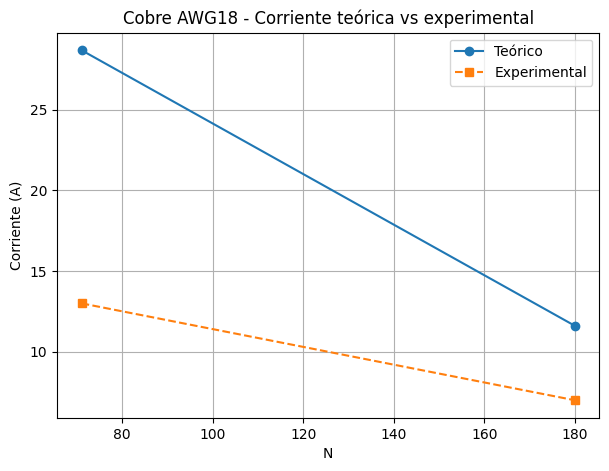

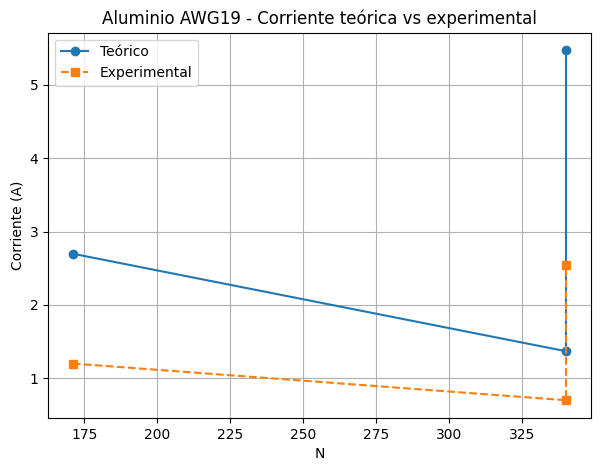

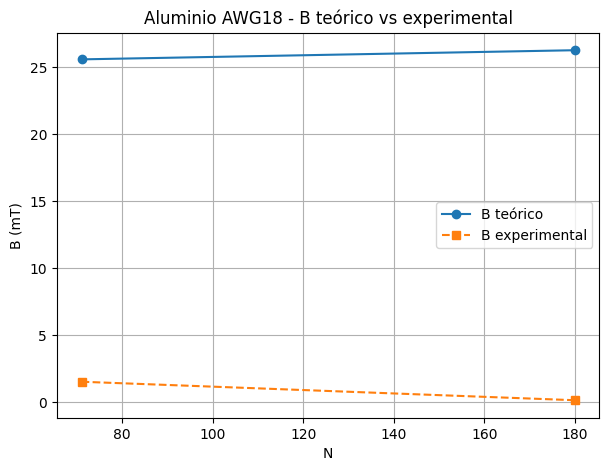

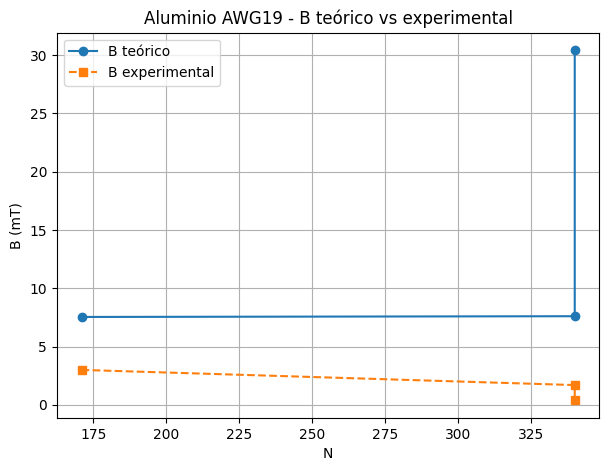

In [ ]:
# ================================================
# 📌 Cálculos teóricos vs experimentales para bobinas
#    Cobre esmaltado AWG 18 y Aluminio esmaltado AWG 19
#    Autor: Adaptado para Google Colab
# ================================================

import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# 1. Constantes y funciones
# -------------------------
mu0 = 4*math.pi*1e-7  # H/m
rho_cu = 1.724e-8     # Ω·m
rho_al = 2.82e-8      # Ω·m

AWG = {
    18: {"diam_mm": 1.024, "area_mm2": 0.823},
    19: {"diam_mm": 0.912, "area_mm2": 0.653},
}

def R_por_metro(awg, material='cu'):
    """Resistencia por metro a 20°C."""
    area = AWG[awg]["area_mm2"] * 1e-6
    rho = rho_cu if material=='cu' else rho_al
    return rho / area

def long_bobina(diam_m, N, extra=1.0):
    """Longitud total incluyendo terminales."""
    return N * (math.pi * diam_m) + extra

def resistencia_bobina(awg, material, diam_m, N, extra=1.0):
    return R_por_metro(awg, material) * long_bobina(diam_m, N, extra)

def B_centro_bobina(N, I, R_m):
    """Campo en el centro de una bobina simple."""
    return mu0 * N * I / (2 * R_m)

def B_centro_helmholtz(N, I, R_m):
    """Campo en el centro de un par Helmholtz."""
    return mu0 * N * I * (4/5)**1.5 / R_m

# ---------------------------------
# 2. Datos experimentales
# ---------------------------------
# Cobre AWG 18 - bobina simple
datos_cobre = [
    {"N":71,  "diam_m":0.10, "V":14.0, "I_exp":13.0, "B_exp":1.52e-3}, # B no medido
    {"N":180, "diam_m":0.10, "V":14.0, "I_exp":7.0,  "B_exp":0.14e-3},
]

# Aluminio AWG 19 - Helmholtz (serie/paralelo)
datos_al = [
    {"N":171, "diam_m":0.11, "V":14.0, "I_exp":1.2,  "B_exp":3e-3,  "config":"Serie"},
    {"N":340, "diam_m":0.11, "V":14.0, "I_exp":0.7,  "B_exp":1.7e-3, "config":"Serie"},
    {"N":340, "diam_m":0.11, "V":14.0, "I_exp":2.54, "B_exp":0.4e-3, "config":"Paralelo"},
]

# ---------------------------------
# 3. Cálculos teóricos
# ---------------------------------
def calcular_teorico_cobre(df_list):
    resultados = []
    for d in df_list:
        R = resistencia_bobina(18, 'cu', d["diam_m"], d["N"])
        I_teo = d["V"] / R
        B_teo = B_centro_bobina(d["N"], I_teo, d["diam_m"]/2)
        resultados.append({
            "N": d["N"], "V (V)": d["V"],
            "I_exp (A)": d["I_exp"], "I_teo (A)": I_teo,
            "Error_I (%)": ((I_teo - d["I_exp"]) / I_teo) * 100,
            "B_exp (mT)": d["B_exp"]*1e3 if d["B_exp"] else None,
            "B_teo (mT)": B_teo*1e3,
            "Error_B (%)": (((B_teo*1e3 - d["B_exp"]*1e3) / B_teo*1e3) * 100) if d["B_exp"] else None
        })
    return pd.DataFrame(resultados)

def calcular_teorico_al(df_list):
    resultados = []
    for d in df_list:
        R_bob = resistencia_bobina(19, 'al', d["diam_m"], d["N"])
        if d["config"] == "Serie":
            R_total = 2 * R_bob
        else:  # Paralelo
            R_total = R_bob / 2
        I_teo = d["V"] / R_total
        B_teo = B_centro_helmholtz(d["N"], I_teo, d["diam_m"]/2)
        resultados.append({
            "N": d["N"], "Config": d["config"], "V (V)": d["V"],
            "I_exp (A)": d["I_exp"], "I_teo (A)": I_teo,
            "Error_I (%)": ((I_teo - d["I_exp"]) / I_teo) * 100,
            "B_exp (mT)": d["B_exp"]*1e3,
            "B_teo (mT)": B_teo*1e3,
            "Error_B (%)": ((B_teo*1e3 - d["B_exp"]*1e3) / B_teo*1e3) * 100
        })
    return pd.DataFrame(resultados)

df_cobre = calcular_teorico_cobre(datos_cobre)
df_al = calcular_teorico_al(datos_al)

print("=== Comparativa Cobre AWG18 (Bobina simple) ===")
print(df_cobre)
print("\n=== Comparativa Aluminio AWG19 (Helmholtz) ===")
print(df_al)

# ---------------------------------
# 4. Gráficas superpuestas
# ---------------------------------
def graficar_comparacion(df, titulo, var_x="N", y_teo="I_teo (A)", y_exp="I_exp (A)", ylabel="Corriente (A)"):
    plt.figure(figsize=(7,5))
    plt.plot(df[var_x], df[y_teo], 'o-', label="Teórico")
    plt.plot(df[var_x], df[y_exp], 's--', label="Experimental")
    plt.xlabel(var_x)
    plt.ylabel(ylabel)
    plt.title(titulo)
    plt.grid(True)
    plt.legend()
    plt.show()

# Corriente
graficar_comparacion(df_cobre, "Cobre AWG18 - Corriente teórica vs experimental", ylabel="Corriente (A)")
graficar_comparacion(df_al, "Aluminio AWG19 - Corriente teórica vs experimental", ylabel="Corriente (A)")

# Campo magnético (solo donde hay datos experimentales)
def graficar_B(df, titulo, var_x="N"):
    plt.figure(figsize=(7,5))
    plt.plot(df[var_x], df["B_teo (mT)"], 'o-', label="B teórico")
    plt.plot(df[var_x], df["B_exp (mT)"], 's--', label="B experimental")
    plt.xlabel(var_x)
    plt.ylabel("B (mT)")
    plt.title(titulo)
    plt.grid(True)
    plt.legend()
    plt.show()

graficar_B(df_cobre, "Aluminio AWG18 - B teórico vs experimental")
graficar_B(df_al, "Aluminio AWG19 - B teórico vs experimental")


                       Caso  R_total (Ω)  L_total (H)   Tau (s)  I_inf (A)  \
0               Cobre_AWG18     1.205515     0.003198  0.002653  11.613292   
1  Aluminio_AWG19_Helmholtz    10.234533     0.037500  0.003664   1.367918   

   B_inf (mT)  
0   26.268647  
1    7.603632  


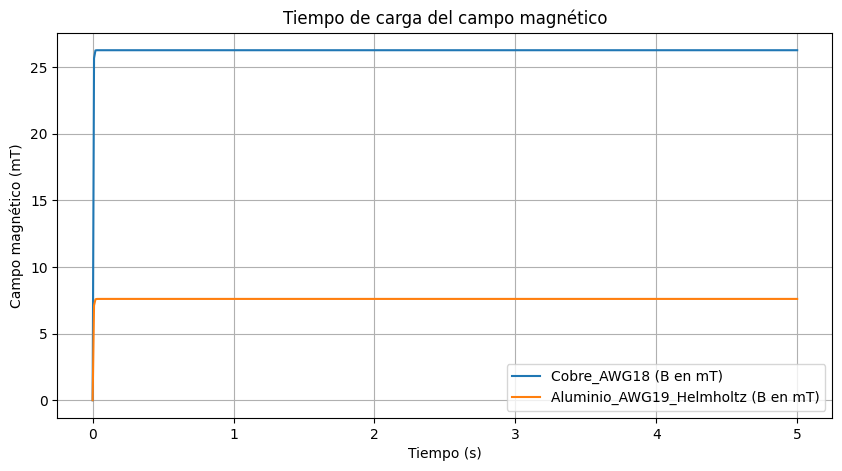

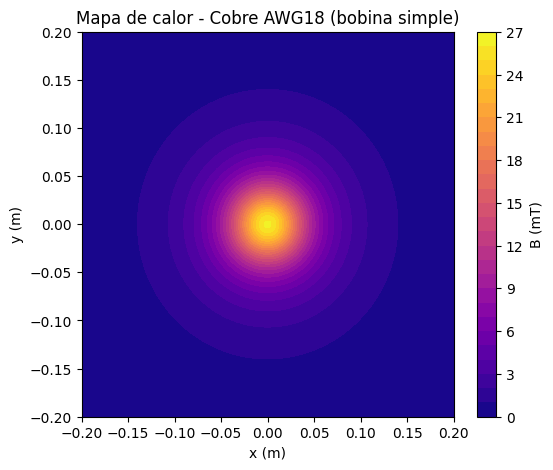


=== Requisitos para alcanzar B objetivo ===
                       Caso  B_obj (mT)  I_req (A)  V_req (V)
0               Cobre_AWG18          20   8.841941  10.659095
1               Cobre_AWG18          30  13.262912  15.988642
2  Aluminio_AWG19_Helmholtz          20   3.598064  36.824507
3  Aluminio_AWG19_Helmholtz          30   5.397096  55.236761


In [ ]:
# ================================================
# 📌 Simulación completa bobinas Cobre AWG18 y Aluminio AWG19
#    Incluye: tiempo de carga, mapas de calor, requisitos para 20 mT y 30 mT
# ================================================

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# 1. Constantes y funciones
# -------------------------
mu0 = 4*math.pi*1e-7  # H/m
rho_cu = 1.724e-8
rho_al = 2.82e-8

AWG = {
    18: {"diam_mm": 1.024, "area_mm2": 0.823},
    19: {"diam_mm": 0.912, "area_mm2": 0.653},
}

def R_por_metro(awg, material='cu'):
    area = AWG[awg]["area_mm2"] * 1e-6
    rho = rho_cu if material=='cu' else rho_al
    return rho / area

def long_bobina(diam_m, N, extra=1.0):
    return N * (math.pi * diam_m) + extra

def resistencia_bobina(awg, material, diam_m, N, extra=1.0):
    return R_por_metro(awg, material) * long_bobina(diam_m, N, extra)

def inductancia_bobina(N, R_m):
    # fórmula de inductancia aproximada para solenoide corto
    return mu0 * N**2 * math.pi * R_m**2 / (2*R_m)  # simplificada

def inductancia_helmholtz(N, R_m):
    L_coil = inductancia_bobina(N, R_m)
    # 2 bobinas en serie más acoplamiento (coeficiente ~0.494 para Helmholtz)
    M = 0.494 * L_coil
    return 2*L_coil + 2*M

def B_centro_bobina(N, I, R_m):
    return mu0 * N * I / (2 * R_m)

def B_centro_helmholtz(N, I, R_m):
    return mu0 * N * I * (4/5)**1.5 / R_m

def respuesta_RL(V, R, L, t):
    I_inf = V/R
    return I_inf * (1 - np.exp(-t / (L/R)))

# ---------------------------------
# 2. Parámetros y casos
# ---------------------------------
casos = {
    "Cobre_AWG18": {"awg":18, "mat":"cu", "diam":0.10, "N":180, "V":14, "tipo":"bobina"},
    "Aluminio_AWG19_Helmholtz": {"awg":19, "mat":"al", "diam":0.11, "N":340, "V":14, "tipo":"helmholtz"}
}

resultados = []

for nombre, c in casos.items():
    R_b = resistencia_bobina(c["awg"], c["mat"], c["diam"], c["N"])
    if c["tipo"]=="helmholtz":
        R_total = 2*R_b
        L_total = inductancia_helmholtz(c["N"], c["diam"]/2)
        B_func = B_centro_helmholtz
    else:
        R_total = R_b
        L_total = inductancia_bobina(c["N"], c["diam"]/2)
        B_func = B_centro_bobina

    tau = L_total / R_total
    I_inf = c["V"]/R_total
    B_inf = B_func(c["N"], I_inf, c["diam"]/2)

    resultados.append({
        "Caso": nombre, "R_total (Ω)": R_total, "L_total (H)": L_total,
        "Tau (s)": tau, "I_inf (A)": I_inf, "B_inf (mT)": B_inf*1e3
    })

df_resultados = pd.DataFrame(resultados)
print(df_resultados)

# ---------------------------------
# 3. Simulación tiempo de carga
# ---------------------------------
t = np.linspace(0, 5, 500)  # 5 segundos
plt.figure(figsize=(10,5))

for nombre, c in casos.items():
    R_b = resistencia_bobina(c["awg"], c["mat"], c["diam"], c["N"])
    if c["tipo"]=="helmholtz":
        R_total = 2*R_b
        L_total = inductancia_helmholtz(c["N"], c["diam"]/2)
        B_func = B_centro_helmholtz
    else:
        R_total = R_b
        L_total = inductancia_bobina(c["N"], c["diam"]/2)
        B_func = B_centro_bobina

    I_t = respuesta_RL(c["V"], R_total, L_total, t)
    B_t = B_func(c["N"], I_t, c["diam"]/2)*1e3
    plt.plot(t, B_t, label=f"{nombre} (B en mT)")

plt.xlabel("Tiempo (s)")
plt.ylabel("Campo magnético (mT)")
plt.title("Tiempo de carga del campo magnético")
plt.grid(True)
plt.legend()
plt.show()

# ---------------------------------
# 4. Mapas de calor del campo
# ---------------------------------
def campo_bobina(x, y, N, I, R_m):
    r = np.sqrt(x**2 + y**2)
    z = 0  # plano central
    # Campo axial aproximado
    return mu0 * N * I * R_m**2 / (2*(R_m**2 + r**2)**1.5)

def mapa_calor_bobina(N, I, R_m, rango=0.2, pasos=100):
    X = np.linspace(-rango, rango, pasos)
    Y = np.linspace(-rango, rango, pasos)
    Bz = np.zeros((pasos, pasos))
    for i, x in enumerate(X):
        for j, y in enumerate(Y):
            Bz[j,i] = campo_bobina(x, y, N, I, R_m)
    return X, Y, Bz*1e3  # mT

# Cobre AWG18
X, Y, Bz = mapa_calor_bobina(180, df_resultados.loc[0,"I_inf (A)"], 0.10/2)
plt.figure(figsize=(6,5))
plt.contourf(X, Y, Bz, levels=30, cmap="plasma")
plt.colorbar(label="B (mT)")
plt.title("Mapa de calor - Cobre AWG18 (bobina simple)")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.show()

# ---------------------------------
# 5. Requisitos para 20 mT y 30 mT
# ---------------------------------
def requisitos_Bobjetivo(B_obj_mT, N, R_m, V_max, R_total, tipo="bobina"):
    B_obj = B_obj_mT/1e3
    k = mu0*N/(2*R_m) if tipo=="bobina" else mu0*N*(4/5)**1.5/R_m
    I_req = B_obj/k
    V_req = I_req * R_total
    return I_req, V_req

objetivos = []
for nombre, c in casos.items():
    R_b = resistencia_bobina(c["awg"], c["mat"], c["diam"], c["N"])
    if c["tipo"]=="helmholtz":
        R_total = 2*R_b
        tipo="helmholtz"
    else:
        R_total = R_b
        tipo="bobina"

    for B_target in [20, 30]:
        I_req, V_req = requisitos_Bobjetivo(B_target, c["N"], c["diam"]/2, 50, R_total, tipo)
        objetivos.append({
            "Caso": nombre, "B_obj (mT)": B_target,
            "I_req (A)": I_req, "V_req (V)": V_req
        })

df_obj = pd.DataFrame(objetivos)
print("\n=== Requisitos para alcanzar B objetivo ===")
print(df_obj)


Resistencia teórica Al AWG19 (340 espiras): 5.074 Ω
Resistencia experimental medida: 3.4 Ω
Diferencia: -33.0 %


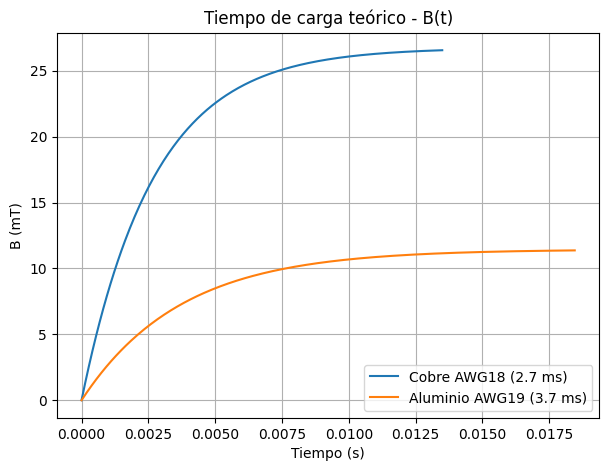

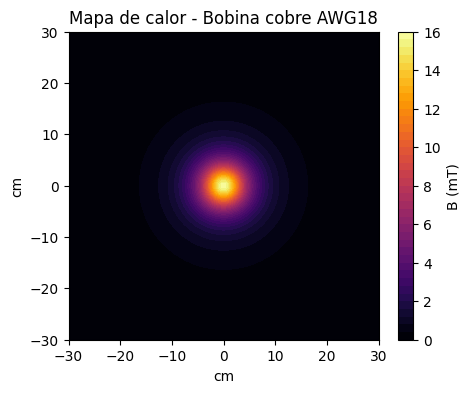

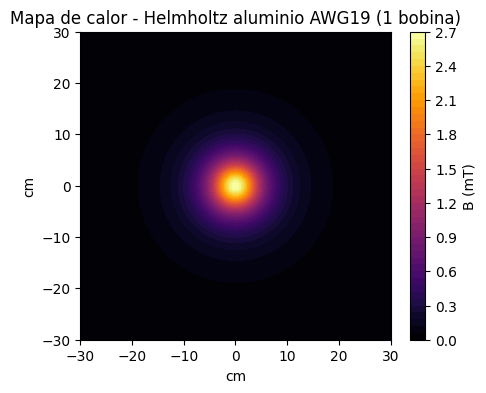

Para 20 mT con N=340, se requiere N*I=1223.3 A·vueltas
Con 340 vueltas, I necesaria = 3.60 A
Para 30 mT con N=340, I necesaria = 5.40 A
Ampacidad segura AWG18: 14 A
Ampacidad segura AWG19: 9 A


In [ ]:
# ================================================
# 📌 Análisis teórico vs experimental de bobinas
#     Cobre AWG 18 (bobina simple) y
#     Aluminio AWG 19 (Helmholtz)
# Incluye: tiempo de carga, mapas de calor, requisitos para 20-30 mT
# ================================================

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Constantes físicas ---
mu0 = 4*math.pi*1e-7   # H/m
rho_cu = 1.724e-8      # Ω·m
rho_al = 2.82e-8       # Ω·m

# --- Datos AWG ---
AWG = {
    18: {"diam_mm": 1.024, "area_mm2": 0.823},
    19: {"diam_mm": 0.912, "area_mm2": 0.653}
}

# --- Funciones base ---
def R_por_metro(awg, material='cu'):
    """Resistencia por metro a 20°C."""
    area = AWG[awg]["area_mm2"] * 1e-6
    rho = rho_cu if material=='cu' else rho_al
    return rho / area

def long_bobina(diam_m, N):
    """Longitud de alambre (sin márgenes)."""
    return N * (math.pi * diam_m)

def resistencia_bobina(awg, material, diam_m, N):
    return R_por_metro(awg, material) * long_bobina(diam_m, N)

def inductancia_bobina(N, R_m):
    """Inductancia de bobina de un solo lazo aproximada."""
    return mu0 * N**2 * math.pi * R_m**2 / (2*R_m)  # simplificación solenoide corto

def inductancia_helmholtz(N, R_m):
    """Inductancia aproximada de un par Helmholtz."""
    L_single = inductancia_bobina(N, R_m)
    return 2*L_single  # simplificación

def B_centro_bobina(N, I, R_m):
    return mu0 * N * I / (2 * R_m)

def B_centro_helmholtz(N, I, R_m):
    return mu0 * N * I * (4/5)**1.5 / R_m

# --- Datos experimentales que diste ---
# Cobre AWG 18
cobre_datos = {"N":180, "diam_m":0.10, "V":14.0, "I_exp":7.0, "B_exp":None}
# Aluminio AWG 19
aluminio_datos = {"N":340, "diam_m":0.11, "V":14.0, "I_exp":0.7, "B_exp":1.7e-3, "R_exp":3.4, "config":"Serie"}

# --- Comparativa resistencia teórica vs experimental ---
R_teo_al = resistencia_bobina(19, 'al', aluminio_datos["diam_m"], aluminio_datos["N"])
print(f"Resistencia teórica Al AWG19 (340 espiras): {R_teo_al:.3f} Ω")
print(f"Resistencia experimental medida: {aluminio_datos['R_exp']} Ω")
print(f"Diferencia: {(aluminio_datos['R_exp'] - R_teo_al)/R_teo_al*100:.1f} %")

# --- Tiempo de carga teórico ---
def tiempo_carga(L, R, V, N, tipo='bobina'):
    """Devuelve arrays de tiempo, corriente y B en régimen transitorio."""
    tau = L / R
    t = np.linspace(0, 5*tau, 300)
    I_inf = V / R
    if tipo=='bobina':
        B_inf = B_centro_bobina(N, I_inf, diam/2)
    else:
        B_inf = B_centro_helmholtz(N, I_inf, diam/2)
    I_t = I_inf * (1 - np.exp(-t/tau))
    B_t = B_inf * (1 - np.exp(-t/tau))
    return t, I_t, B_t, tau

# Caso cobre AWG18
R_cu = resistencia_bobina(18, 'cu', cobre_datos["diam_m"], cobre_datos["N"])
L_cu = inductancia_bobina(cobre_datos["N"], cobre_datos["diam_m"]/2)
diam = cobre_datos["diam_m"]
t_cu, I_cu, B_cu, tau_cu = tiempo_carga(L_cu, R_cu, cobre_datos["V"], cobre_datos["N"], tipo='bobina')

# Caso aluminio AWG19
R_al = aluminio_datos["R_exp"]*2  # serie, dos bobinas
L_al = inductancia_helmholtz(aluminio_datos["N"], aluminio_datos["diam_m"]/2)
diam = aluminio_datos["diam_m"]
t_al, I_al, B_al, tau_al = tiempo_carga(L_al, R_al, aluminio_datos["V"], aluminio_datos["N"], tipo='helmholtz')

# --- Graficar tiempos de carga ---
plt.figure(figsize=(7,5))
plt.plot(t_cu, B_cu*1e3, label=f"Cobre AWG18 ({tau_cu*1000:.1f} ms)")
plt.plot(t_al, B_al*1e3, label=f"Aluminio AWG19 ({tau_al*1000:.1f} ms)")
plt.xlabel("Tiempo (s)")
plt.ylabel("B (mT)")
plt.title("Tiempo de carga teórico - B(t)")
plt.grid(True)
plt.legend()
plt.show()

# --- Mapas de calor ---
def mapa_calor_bobina(N, I, R_m, grid=0.1, size=0.3):
    x = np.linspace(-size, size, 100)
    y = np.linspace(-size, size, 100)
    X, Y = np.meshgrid(x, y)
    Z = np.zeros_like(X)
    for i in range(len(x)):
        for j in range(len(y)):
            r = np.sqrt(X[i,j]**2 + Y[i,j]**2 + R_m**2)
            Z[i,j] = mu0 * N * I * R_m**2 / (2 * r**3)
    return X, Y, Z

# Bobina cobre
X_cu, Y_cu, Z_cu = mapa_calor_bobina(cobre_datos["N"], cobre_datos["I_exp"], cobre_datos["diam_m"]/2)
plt.figure(figsize=(5,4))
plt.contourf(X_cu*100, Y_cu*100, Z_cu*1e3, 50, cmap='inferno')
plt.colorbar(label="B (mT)")
plt.title("Mapa de calor - Bobina cobre AWG18")
plt.xlabel("cm")
plt.ylabel("cm")
plt.show()

# Helmholtz aluminio (superposición simple)
X_al, Y_al, Z_al = mapa_calor_bobina(aluminio_datos["N"], aluminio_datos["I_exp"], aluminio_datos["diam_m"]/2)
plt.figure(figsize=(5,4))
plt.contourf(X_al*100, Y_al*100, Z_al*1e3, 50, cmap='inferno')
plt.colorbar(label="B (mT)")
plt.title("Mapa de calor - Helmholtz aluminio AWG19 (1 bobina)")
plt.xlabel("cm")
plt.ylabel("cm")
plt.show()

# --- Requisitos para llegar a 20 mT y 30 mT ---
def requisitos_Bobjetivo(B_obj_mT, N, R_m):
    NI_req = (B_obj_mT/1e3) * R_m / (mu0 * (4/5)**1.5)
    return NI_req

B20 = requisitos_Bobjetivo(20, aluminio_datos["N"], aluminio_datos["diam_m"]/2)
B30 = requisitos_Bobjetivo(30, aluminio_datos["N"], aluminio_datos["diam_m"]/2)

print(f"Para 20 mT con N={aluminio_datos['N']}, se requiere N*I={B20:.1f} A·vueltas")
print(f"Con {aluminio_datos['N']} vueltas, I necesaria = {B20/aluminio_datos['N']:.2f} A")
print(f"Para 30 mT con N={aluminio_datos['N']}, I necesaria = {B30/aluminio_datos['N']:.2f} A")

# --- Verificación de capacidad de conducción de corriente ---
ampacidad_AWG = {18: 14, 19: 9}  # Aproximado en A para uso continuo
print(f"Ampacidad segura AWG18: {ampacidad_AWG[18]} A")
print(f"Ampacidad segura AWG19: {ampacidad_AWG[19]} A")


Resistencia teórica Al AWG19 (340 espiras): 5.074 Ω
Resistencia experimental medida (1 bobina): 3.4 Ω
Diferencia: -33.0 %


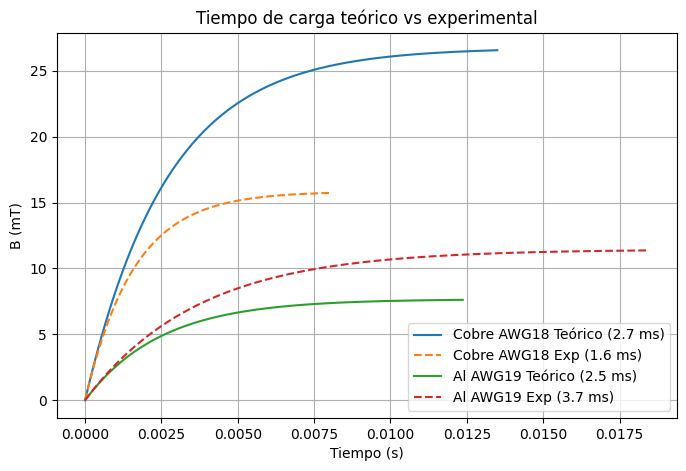

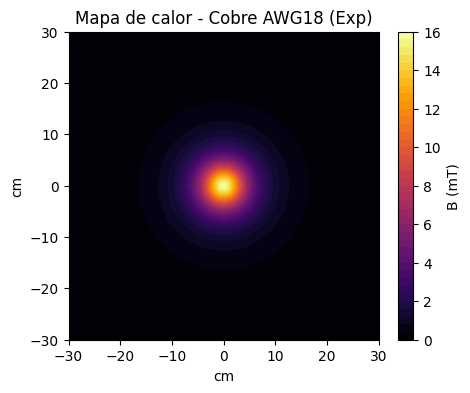

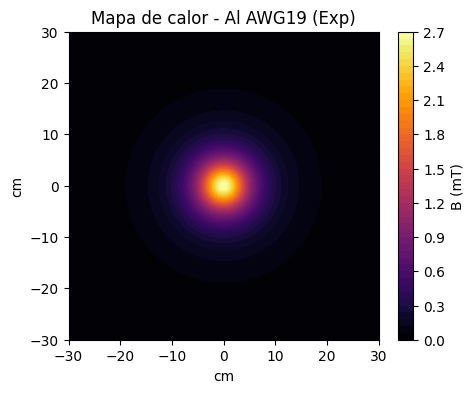

Objetivo 20 mT -> N*I = 1223.3 A·vueltas, I necesaria con N=340: 3.60 A
Objetivo 30 mT -> N*I = 1835.0 A·vueltas, I necesaria con N=340: 5.40 A
Ampacidad segura AWG18: 14 A
Ampacidad segura AWG19: 9 A


In [ ]:
# ================================================
# 📌 Análisis teórico vs experimental de bobinas
#     Cobre AWG 18 (bobina simple) y
#     Aluminio AWG 19 (Helmholtz)
# Incluye: tiempo de carga, mapas de calor,
# requisitos para 20-30 mT y comparación teórico/experimental
# ================================================

import math
import numpy as np
import matplotlib.pyplot as plt

# --- Constantes físicas ---
mu0 = 4*math.pi*1e-7   # H/m
rho_cu = 1.724e-8      # Ω·m
rho_al = 2.82e-8       # Ω·m

# --- Datos AWG ---
AWG = {
    18: {"diam_mm": 1.024, "area_mm2": 0.823},
    19: {"diam_mm": 0.912, "area_mm2": 0.653}
}

# --- Funciones base ---
def R_por_metro(awg, material='cu'):
    """Resistencia por metro a 20°C."""
    area = AWG[awg]["area_mm2"] * 1e-6
    rho = rho_cu if material=='cu' else rho_al
    return rho / area

def long_bobina(diam_m, N):
    """Longitud de alambre (sin márgenes)."""
    return N * (math.pi * diam_m)

def resistencia_bobina(awg, material, diam_m, N):
    return R_por_metro(awg, material) * long_bobina(diam_m, N)

def inductancia_bobina(N, R_m):
    """Inductancia aproximada para bobina corta."""
    return mu0 * N**2 * math.pi * R_m**2 / (2 * R_m)

def inductancia_helmholtz(N, R_m):
    """Inductancia aproximada de un par Helmholtz."""
    L_single = inductancia_bobina(N, R_m)
    return 2*L_single

def B_centro_bobina(N, I, R_m):
    return mu0 * N * I / (2 * R_m)

def B_centro_helmholtz(N, I, R_m):
    return mu0 * N * I * (4/5)**1.5 / R_m

# --- Datos experimentales ---
cobre = {"N":180, "diam_m":0.10, "V":14.0, "I_exp":7.0, "R_exp":14.0/7.0, "B_exp":None, "config":"bobina"}
aluminio = {"N":340, "diam_m":0.11, "V":14.0, "I_exp":0.7, "B_exp":1.7e-3, "R_exp":3.4, "config":"serie"} # R_exp por bobina

# --- Comparativa resistencia teórica vs experimental ---
R_teo_al = resistencia_bobina(19, 'al', aluminio["diam_m"], aluminio["N"])
print(f"Resistencia teórica Al AWG19 (340 espiras): {R_teo_al:.3f} Ω")
print(f"Resistencia experimental medida (1 bobina): {aluminio['R_exp']} Ω")
print(f"Diferencia: {(aluminio['R_exp'] - R_teo_al)/R_teo_al*100:.1f} %")

# --- Tiempo de carga (teórico y experimental) ---
def tiempo_carga(L, R, V, N, diam_m, tipo='bobina'):
    tau = L / R
    t = np.linspace(0, 5*tau, 300)
    I_inf = V / R
    if tipo=='bobina':
        B_inf = B_centro_bobina(N, I_inf, diam_m/2)
    else:
        B_inf = B_centro_helmholtz(N, I_inf, diam_m/2)
    I_t = I_inf * (1 - np.exp(-t/tau))
    B_t = B_inf * (1 - np.exp(-t/tau))
    return t, I_t, B_t, tau

# --- Teórico cobre ---
R_cu_teo = resistencia_bobina(18, 'cu', cobre["diam_m"], cobre["N"])
L_cu = inductancia_bobina(cobre["N"], cobre["diam_m"]/2)
t_cu_teo, I_cu_teo, B_cu_teo, tau_cu_teo = tiempo_carga(L_cu, R_cu_teo, cobre["V"], cobre["N"], cobre["diam_m"], tipo='bobina')

# --- Experimental cobre ---
t_cu_exp, I_cu_exp, B_cu_exp, tau_cu_exp = tiempo_carga(L_cu, cobre["R_exp"], cobre["V"], cobre["N"], cobre["diam_m"], tipo='bobina')

# --- Teórico aluminio ---
R_al_teo_total = R_teo_al * 2  # serie
L_al = inductancia_helmholtz(aluminio["N"], aluminio["diam_m"]/2)
t_al_teo, I_al_teo, B_al_teo, tau_al_teo = tiempo_carga(L_al, R_al_teo_total, aluminio["V"], aluminio["N"], aluminio["diam_m"], tipo='helmholtz')

# --- Experimental aluminio ---
R_al_exp_total = aluminio["R_exp"] * 2  # serie
t_al_exp, I_al_exp, B_al_exp, tau_al_exp = tiempo_carga(L_al, R_al_exp_total, aluminio["V"], aluminio["N"], aluminio["diam_m"], tipo='helmholtz')

# --- Gráficas superpuestas tiempo de carga ---
plt.figure(figsize=(8,5))
plt.plot(t_cu_teo, B_cu_teo*1e3, label=f"Cobre AWG18 Teórico ({tau_cu_teo*1000:.1f} ms)")
plt.plot(t_cu_exp, B_cu_exp*1e3, '--', label=f"Cobre AWG18 Exp ({tau_cu_exp*1000:.1f} ms)")
plt.plot(t_al_teo, B_al_teo*1e3, label=f"Al AWG19 Teórico ({tau_al_teo*1000:.1f} ms)")
plt.plot(t_al_exp, B_al_exp*1e3, '--', label=f"Al AWG19 Exp ({tau_al_exp*1000:.1f} ms)")
plt.xlabel("Tiempo (s)")
plt.ylabel("B (mT)")
plt.title("Tiempo de carga teórico vs experimental")
plt.grid(True)
plt.legend()
plt.show()

# --- Mapas de calor ---
def mapa_calor_bobina(N, I, R_m, grid=0.15, size=0.3):
    x = np.linspace(-size, size, 100)
    y = np.linspace(-size, size, 100)
    X, Y = np.meshgrid(x, y)
    Z = np.zeros_like(X)
    for i in range(len(x)):
        for j in range(len(y)):
            r = np.sqrt(X[i,j]**2 + Y[i,j]**2 + R_m**2)
            Z[i,j] = mu0 * N * I * R_m**2 / (2 * r**3)
    return X, Y, Z

# Bobina cobre
X_cu, Y_cu, Z_cu = mapa_calor_bobina(cobre["N"], cobre["I_exp"], cobre["diam_m"]/2)
plt.figure(figsize=(5,4))
plt.contourf(X_cu*100, Y_cu*100, Z_cu*1e3, 50, cmap='inferno')
plt.colorbar(label="B (mT)")
plt.title("Mapa de calor - Cobre AWG18 (Exp)")
plt.xlabel("cm")
plt.ylabel("cm")
plt.show()

# Helmholtz aluminio (1 bobina)
X_al, Y_al, Z_al = mapa_calor_bobina(aluminio["N"], aluminio["I_exp"], aluminio["diam_m"]/2)
plt.figure(figsize=(5,4))
plt.contourf(X_al*100, Y_al*100, Z_al*1e3, 50, cmap='inferno')
plt.colorbar(label="B (mT)")
plt.title("Mapa de calor - Al AWG19 (Exp)")
plt.xlabel("cm")
plt.ylabel("cm")
plt.show()

# --- Requisitos para 20 mT y 30 mT ---
def NI_para_B(B_mT, R_m):
    return (B_mT/1e3) * R_m / (mu0 * (4/5)**1.5)

for objetivo in [20, 30]:
    NI = NI_para_B(objetivo, aluminio["diam_m"]/2)
    I_nec = NI / aluminio["N"]
    print(f"Objetivo {objetivo} mT -> N*I = {NI:.1f} A·vueltas, I necesaria con N={aluminio['N']}: {I_nec:.2f} A")

# --- Ampacidad segura ---
ampacidad_AWG = {18: 14, 19: 9}  # Aprox en A
print(f"Ampacidad segura AWG18: {ampacidad_AWG[18]} A")
print(f"Ampacidad segura AWG19: {ampacidad_AWG[19]} A")
